# Catalog EDA Template

Use this notebook after a catalog has been fetched and converted into a processed Parquet dataset.

Suggested scope:
- inspect schema
- review missingness
- summarize redshift and other numeric fields
- visualize basic distributions

Out of scope for now:
- anomaly detection
- outlier hunting
- model fitting beyond basic descriptive analysis


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from jwst_galaxy_analysis.config import get_paths

sns.set_theme(context='notebook', style='whitegrid')
paths = get_paths()
dataset_path = paths.data_processed / 'astrodeep_jwst.parquet'
dataset_path


mkdir -p failed for path C:\Users\Odet\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\Odet\\.matplotlib'


Matplotlib created a temporary cache directory at C:\Users\Odet\AppData\Local\Temp\matplotlib-30r10x5e because there was an issue with the default path (C:\Users\Odet\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


WindowsPath('D:/Cosmos/data/processed/astrodeep_jwst.parquet')

In [2]:
if not dataset_path.exists():
    raise FileNotFoundError('Expected processed dataset at data/processed/astrodeep_jwst.parquet')

df = pd.read_parquet(dataset_path)
df.head()


,id,raj2000,dej2000,zspec,zphot,eazyeazyv13,eazylarson,eazylarsonlyared,flag
0,1,3.616064,-30.461614,NaN,19.850000,19.903999,19.903999,19.903999,100028
1,2,3.616645,-30.460626,NaN,0.800000,0.759000,0.823000,0.823000,28
2,3,3.618336,-30.460675,NaN,2.450000,5.302000,5.125000,5.125000,28
3,4,3.620353,-30.458455,NaN,1.200000,1.293000,1.447000,1.447000,28
4,5,3.616128,-30.460539,NaN,16.674999,17.117001,16.572001,16.974001,100028


In [3]:
print(f'Row count: {len(df):,}')
print(f'Column count: {len(df.columns):,}')
print('\nColumn names:')
for column in df.columns:
    print(f'- {column}')


Row count: 250
Column count: 9

Column names:
- id
- raj2000
- dej2000
- zspec
- zphot
- eazyeazyv13
- eazylarson
- eazylarsonlyared
- flag


In [4]:
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_fraction': df.isna().mean(),
    'dtype': df.dtypes.astype(str),
})
missing_summary.sort_values(['missing_count', 'missing_fraction'], ascending=False)


,missing_count,missing_fraction,dtype
zspec,248,0.992,float32
zphot,1,0.004,float32
id,0,0.000,int32
raj2000,0,0.000,float64
dej2000,0,0.000,float64
eazyeazyv13,0,0.000,float32
eazylarson,0,0.000,float32
eazylarsonlyared,0,0.000,float32
flag,0,0.000,int32


Using redshift column: zphot


count    249.000000
mean       3.872514
std        3.777501
min        0.050000
25%        1.475000
50%        3.200000
75%        4.925000
max       19.850000
Name: zphot, dtype: float64

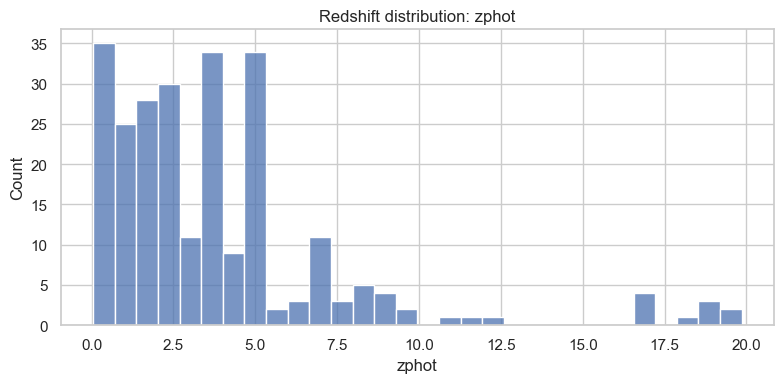

In [5]:
redshift_candidates = [
    column for column in ['zphot', 'zspec', 'z', 'zbest']
    if column in df.columns
]

if redshift_candidates:
    redshift_column = redshift_candidates[0]
    print(f'Using redshift column: {redshift_column}')
    display(df[redshift_column].describe())
    plt.figure(figsize=(8, 4))
    sns.histplot(df[redshift_column].dropna(), bins=30)
    plt.title(f'Redshift distribution: {redshift_column}')
    plt.xlabel(redshift_column)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(paths.figures / f'{dataset_path.stem}_{redshift_column}_distribution.png', dpi=150)
else:
    print('No redshift-like column found.')


In [6]:
numeric_stats = df.select_dtypes(include='number').describe().transpose()
numeric_stats


,count,mean,std,min,25%,50%,75%,max
id,250.0,125.500000,72.312977,1.000000,63.250000,125.500000,187.750000,250.000000
raj2000,250.0,3.619410,0.005774,3.606694,3.614928,3.618739,3.623951,3.633511
dej2000,250.0,-30.455778,0.002358,-30.461614,-30.457348,-30.455399,-30.453945,-30.448283
zspec,2.0,0.303000,0.007071,0.298000,0.300500,0.303000,0.305500,0.308000
zphot,249.0,3.872514,3.777501,0.050000,1.475000,3.200000,4.925000,19.850000
eazyeazyv13,250.0,4.386589,4.218722,0.199000,1.609000,3.417000,5.300750,19.903999
eazylarson,250.0,4.756912,4.245658,0.104000,1.707750,3.757500,5.849000,19.903999
eazylarsonlyared,250.0,4.728344,4.169399,0.104000,1.707750,3.757500,5.849000,19.903999
flag,250.0,8902.720000,32149.177235,18.000000,28.000000,28.000000,128.000000,140748.000000
